## Regime Detection in Financial Markets using Machine Learning (Data Download — FTSE 100 / FTSE 250 / FTSE 350)
- Author: Abbinav Sankar Kailasam (UCL)
- Supervisors: Dr. Blaz Zlicar (ADIA), Prof. Fabio Caccioli (UCL)

In [37]:
# Standard library, HTTP, and data/finance imports.
from io import StringIO

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from plot_style import set_publication_style, style_axis, format_date_axis, NEUTRAL_COLOURS

set_publication_style()

In [38]:
# Global date range and batch size for the download.
START_DATE  = "2001-01-01"
END_DATE    = "2026-07-15"
BATCH_SIZE  = 50

In [39]:
# ICB sector string to short code, shared by FTSE 100 and FTSE 250.
FTSE_SECTOR_MAP = {
    "Aerospace & Defence": "IND",
    "Aerospace & defence": "IND",
    "Alternative Energy": "ENE",
    "Automobiles & Parts": "CD",
    "Banking": "FIN",
    "Banking Services": "FIN",
    "Banks": "FIN",
    "Basic Resources": "MAT",
    "Beverages": "CST",
    "Chemicals": "MAT",
    "Collective Investments": "FIN",
    "Collective investments": "FIN",
    "Construction": "IND",
    "Construction & Materials": "IND",
    "Consumer Digital Services": "CD",
    "Consumer Staples": "CST",
    "Containers & packaging": "MAT",
    "Electrical utilities & independent power producers": "UTL",
    "Electricity": "UTL",
    "Electronic & Electrical Equipment": "IND",
    "Electronic equipment & parts": "IND",
    "Energy": "ENE",
    "Engineering and Construction": "IND",
    "Equity Investments": "FIN",
    "Financial Services": "FIN",
    "Financial services": "FIN",
    "Food & Drug Retailers": "CST",
    "Food & drug retailers": "CST",
    "Food & drug retailing": "CST",
    "Food & tobacco": "CST",
    "Food Producers": "CST",
    "Food and drink": "CST",
    "Food, Beverage and Tobacco": "CST",
    "Gas, Water & Multiutilities": "UTL",
    "General Financial": "FIN",
    "General Industrials": "IND",
    "General industrials": "IND",
    "General retailers": "CD",
    "Health Care": "HC",
    "Health Care Equipment & Services": "HC",
    "Health care equipment & supplies": "HC",
    "Hedge Funds": "FIN",
    "Home Construction": "IND",
    "Homebuilding & construction supplies": "IND",
    "Household goods & home construction": "IND",
    "Industrial Engineering": "IND",
    "Industrial engineering": "IND",
    "Industrial Goods and Services": "IND",
    "Industrial goods and services": "IND",
    "Industrial Metals and Mining": "MAT",
    "Industrial Support Services": "IND",
    "Industrial Support services": "IND",
    "Industrial Transportation": "IND",
    "Industrials": "IND",
    "Insurance": "FIN",
    "Investment Banking and Brokerage Services": "FIN",
    "Investment Trusts": "FIN",
    "Investment trusts": "FIN",
    "Leisure Goods": "CD",
    "Life Insurance": "FIN",
    "Life insurance": "FIN",
    "Media": "CD",
    "Mining": "MAT",
    "Mobile telecommunications": "TEL",
    "Multiline utilities": "UTL",
    "Non-life Insurance": "FIN",
    "Nonlife Insurance": "FIN",
    "Oil & Gas Producers": "ENE",
    "Oil & gas producers": "ENE",
    "Oil, Gas and Coal": "ENE",
    "Personal Goods": "CD",
    "Personal goods": "CD",
    "Personal Products": "CST",
    "Pharmaceuticals & Biotechnology": "HC",
    "Pharmaceuticals & biotechnology": "HC",
    "Pharmaceuticals and Biotechnology": "HC",
    "Precious Metals and Mining": "MAT",
    "Real Estate": "RE",
    "Real estate": "RE",
    "Real Estate Investment & Services": "RE",
    "Real Estate Investment Trusts": "RE",
    "Real estate investment trusts": "RE",
    "Retail": "CD",
    "Retail hospitality": "CD",
    "Retailers": "CD",
    "Software & Computer Services": "TECH",
    "Software & computer services": "TECH",
    "Software and Computer Services": "TECH",
    "Support Services": "IND",
    "Support services": "IND",
    "Technology": "TECH",
    "Telecomms": "TEL",
    "Telecommunications": "TEL",
    "Telecommunications services": "TEL",
    "Tobacco": "CST",
    "Travel & Leisure": "CD",
    "Travel & leisure": "CD",
    "Travel and Leisure": "CD",
    "Travel and leisure": "CD",
}

In [40]:
# Per-index scrape/ticker-map configuration consumed by fetch_constituents.
INDICES = {
    "FTSE250": {
        "name": "FTSE 250",
        "wiki_url": "https://en.wikipedia.org/wiki/FTSE_250_Index",
        "table_match": "ftse industry classification benchmark sector",
        "symbol_col": "Ticker",
        "suffix": ".L",
        "sector_map": FTSE_SECTOR_MAP,
    },
    "FTSE100": {
        "name": "FTSE 100",
        "wiki_url": "https://en.wikipedia.org/wiki/FTSE_100_Index",
        "table_match": "ftse industry classification benchmark sector",
        "symbol_col": "Ticker",
        "suffix": ".L",
        "sector_map": FTSE_SECTOR_MAP,
    },
}

In [41]:
# Build the ticker map for one index from its INDICES config
def fetch_constituents(index_code):
    cfg = INDICES[index_code]

    if "wiki_url" in cfg:
        html = requests.get(cfg["wiki_url"], headers={"User-Agent": "Mozilla/5.0"}).text
        tables = pd.read_html(StringIO(html))

        if "table_match" in cfg:
            df, sector_col = None, None
            for t in tables:
                cols = [str(c) for c in t.columns]
                match = next((c for c in cols if c.lower().startswith(cfg["table_match"])), None)
                if cfg["symbol_col"] in cols and match:
                    df, sector_col = t.dropna(subset=[cfg["symbol_col"]]), match
                    break
            if df is None:
                raise ValueError(f"No table on {cfg['wiki_url']} has {cfg['symbol_col']!r} and a column starting with {cfg['table_match']!r}")
        else:
            df = tables[cfg["table_index"]]
            sector_col = cfg["sector_col"]

        ticker_map = {}
        for _, row in df.iterrows():
            raw_symbol = row[cfg["symbol_col"]]
            if "suffix_col" in cfg:
                _, sep, code = raw_symbol.partition(":")
                if not sep:
                    raise ValueError(f"{cfg['name']}: expected 'PREFIX: CODE' in symbol {raw_symbol!r}")
                epic = code.strip().replace(".", "-")
                exch = row[cfg["suffix_col"]]
                if exch not in cfg["suffix_map"]:
                    raise ValueError(f"{cfg['name']}: exchange {exch!r} not in suffix_map for symbol {raw_symbol!r}")
                suffix = cfg["suffix_map"][exch]
            else:
                epic = raw_symbol.replace(".", "-")
                suffix = cfg.get("suffix", "")
            tk = epic + suffix
            sector_name = row[sector_col]
            if sector_name not in cfg["sector_map"]:
                print(f"WARNING: {cfg['name']} sector {sector_name!r} not in sector_map, falling back to a derived code")
            sector = cfg["sector_map"].get(sector_name, sector_name.replace(" ", "_").upper())
            ticker_map[tk] = f"{sector}_{epic}"

        n_sectors = df[sector_col].nunique()
        print(f"Found {len(ticker_map)} {cfg['name']} tickers across {n_sectors} sectors")
        return ticker_map

    ticker_map = {}
    for sector, codes in cfg["components"].items():
        for code in codes:
            tk = f"{code}{cfg['suffix']}"
            ticker_map[tk] = f"{sector}_{code}"

    n_sectors = len(cfg["components"])
    print(f"Found {len(ticker_map)} {cfg['name']} tickers across {n_sectors} sectors "
          f"({cfg['snapshot']} snapshot)")
    return ticker_map

In [42]:
# Batched yfinance download of adjusted close prices for a ticker map, index-agnostic.
def download_prices(ticker_map, start_date, end_date, batch_size=BATCH_SIZE):
    tickers = list(ticker_map.keys())
    batches = [tickers[i:i + batch_size] for i in range(0, len(tickers), batch_size)]

    all_frames = []
    for idx, batch in enumerate(batches, 1):
        print(f"Batch {idx}/{len(batches)}: {batch[0]} … {batch[-1]}", end="  ")
        raw = yf.download(tickers=batch, start=start_date, end=end_date,
                          auto_adjust=True, progress=False, threads=True)

        if isinstance(raw.columns, pd.MultiIndex):
            close = raw["Close"]
        else:
            close = raw[["Close"]].rename(columns={"Close": batch[0]})

        all_frames.append(close)
        print(f"→ {close.shape[1]} tickers, {close.shape[0]} rows")

    df = pd.concat(all_frames, axis=1)
    df.index.name = "Date"
    df.sort_index(inplace=True)
    df.rename(columns=ticker_map, inplace=True)
    return df

In [43]:
# Drop broken adjustments, unadjusted corporate actions, short histories, non-trading days, and prolonged trading halts.
def screen_panel(df):
    bad_price = df.columns[(df <= 0).any()]
    df = df.drop(columns=bad_price)

    r = np.log(df).diff()
    bad_jump = r.columns[(r.abs() > 0.8).any()]
    df = df.drop(columns=bad_jump)

    n_before = df.shape[1]
    df = df.dropna(how="any", axis=1)
    n_incomplete = n_before - df.shape[1]

    r = np.log(df).diff()
    flat = (r.abs() < 1e-12).mean(axis=1) > 0.98
    df = df.loc[~flat]

    HALT_STREAK_DAYS = 63
    r = np.log(df).diff()
    flat_by_stock = r.abs() < 1e-12
    longest_halt = flat_by_stock.apply(lambda s: s.groupby((~s).cumsum()).cumsum().max())
    bad_halt = longest_halt[longest_halt >= HALT_STREAK_DAYS].index
    df = df.drop(columns=bad_halt)

    print(f"non-positive prices : {list(bad_price)}")
    print(f"unadjusted actions  : {list(bad_jump)}")
    print(f"incomplete history  : {n_incomplete} names")
    print(f"non-trading days    : {int(flat.sum())} rows")
    print(f"prolonged halts     : {list(bad_halt)}")
    return df

In [44]:
# Fetch constituents, download prices, clean, and save data/{index_code}_AdjClose_{Raw,Cleaned}.csv.
def download_index(index_code, start_date, end_date, batch_size=BATCH_SIZE):
    ticker_map = fetch_constituents(index_code)
    df_raw = download_prices(ticker_map, start_date, end_date, batch_size)
    df_raw.to_csv(f"data/{index_code}_AdjClose_Raw.csv", index=True)

    df_clean = screen_panel(df_raw)
    print(df_clean.shape)
    df_clean.to_csv(f"data/{index_code}_AdjClose_Cleaned.csv", index=True)
    return df_clean

In [45]:
# Download and clean the FTSE 250 panel.
df_ftse250 = download_index("FTSE250", START_DATE, END_DATE)

Found 250 FTSE 250 tickers across 67 sectors
Batch 1/5: 3IN.L … COST.L  → 50 tickers, 6492 rows
Batch 2/5: CWK.L … HFEL.L  → 50 tickers, 6492 rows
Batch 3/5: HSL.L … MGNS.L  → 50 tickers, 6492 rows
Batch 4/5: MUT.L … ATR.L  → 50 tickers, 6492 rows
Batch 5/5: SDP.L … ZIG.L  → 50 tickers, 6492 rows
non-positive prices : []
unadjusted actions  : ['FIN_AAS', 'FIN_AGT', 'FIN_BNKR', 'FIN_CLDN', 'ENE_CWR', 'MAT_ELM', 'FIN_ESCT', 'CD_FRAS', 'CD_INCH', 'FIN_JEGI', 'CD_MEGP', 'FIN_MNKS', 'FIN_MRC', 'FIN_MYI', 'FIN_NAS', 'HC_OXB', 'FIN_PIN', 'FIN_PNL', 'CD_PPH', 'TECH_PTEC', 'IND_ROSE', 'RE_SHC', 'FIN_TEM', 'FIN_TMPL', 'FIN_WWH']
incomplete history  : 119 names
non-trading days    : 12 rows
prolonged halts     : ['IND_DATA', 'RE_HWG', 'IND_HILS', 'MAT_PAF', 'IND_XPP']
(6480, 101)


In [46]:
# Download and clean the FTSE 100 panel.
df_ftse100 = download_index("FTSE100", START_DATE, END_DATE)

Found 100 FTSE 100 tickers across 44 sectors
Batch 1/2: III.L … IMB.L  → 50 tickers, 6492 rows
Batch 2/2: INF.L … WTB.L  → 50 tickers, 6492 rows
non-positive prices : []
unadjusted actions  : ['FIN_NWG', 'FIN_PCT']
incomplete history  : 38 names
non-trading days    : 12 rows
prolonged halts     : ['IND_BTRW', 'ENE_SHEL']
(6480, 58)


In [47]:
# Concatenate the FTSE 100 and FTSE 250 panels into one FTSE 350 panel.
df_ftse350 = pd.concat([df_ftse100, df_ftse250], axis=1, join="inner")
df_ftse350.to_csv("data/FTSE350_AdjClose_Cleaned.csv", index=True)

In [48]:
df_ftse250_raw = pd.read_csv("data/FTSE250_AdjClose_Raw.csv", index_col="Date", parse_dates=True)
df_ftse250_raw.head()

,FIN_3IN,FIN_AAS,CST_AEP,FIN_AGT,FIN_AIE,FIN_AJB,TECH_ALFA,CD_AML,CD_AO,CST_APN,...,IND_VTY,CD_WIX,CD_WIZZ,RE_WKP,CD_WOSG,CD_WPP,FIN_WWH,IND_XPP,FIN_XPS,IND_ZIG
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-01,NaN,18.166372,4.383925,36.745399,NaN,NaN,NaN,NaN,NaN,NaN,...,340.775513,NaN,NaN,773.777283,NaN,865.598389,63.430317,1015.522278,NaN,809.922424
2001-01-02,NaN,18.017069,4.383925,36.795189,NaN,NaN,NaN,NaN,NaN,NaN,...,340.293396,NaN,NaN,763.597229,NaN,820.928711,63.130878,1025.453735,NaN,806.691223
2001-01-03,NaN,17.668676,4.383925,36.446651,NaN,NaN,NaN,NaN,NaN,NaN,...,340.293396,NaN,NaN,765.032593,NaN,781.222534,61.733517,983.243774,NaN,804.537415
2001-01-04,NaN,18.017069,4.334107,37.093925,NaN,NaN,NaN,NaN,NaN,NaN,...,345.595428,NaN,NaN,767.903381,NaN,873.539734,61.284370,1000.624390,NaN,804.537415
2001-01-05,NaN,18.216150,4.334107,37.143703,NaN,NaN,NaN,NaN,NaN,NaN,...,355.717529,NaN,NaN,771.491699,NaN,858.649780,57.641243,960.897461,NaN,799.152161


In [49]:
df_ftse100_raw = pd.read_csv("data/FTSE100_AdjClose_Raw.csv", index_col="Date", parse_dates=True)
df_ftse100_raw.head()

,TEL_AAF,MAT_AAL,FIN_ABDN,CST_ABF,FIN_ADM,FIN_ALW,MAT_ANTO,CD_AUTO,FIN_AV,HC_AZN,...,UTL_SSE,FIN_STAN,FIN_STJ,UTL_SVT,CST_TSCO,CD_ULVR,UTL_UU,TEL_VOD,IND_WEIR,CD_WTB
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-01,NaN,980.745728,NaN,500.718689,NaN,316.832581,87.708427,NaN,1050.992310,3345.539307,...,611.700684,768.168274,421.188965,1101.322754,342.176880,1349.473755,654.687500,287.572479,235.960281,727.863281
2001-01-02,NaN,976.758850,NaN,518.370605,NaN,317.329590,88.005707,NaN,1046.135620,3355.452148,...,618.607178,756.619934,426.652557,1082.079224,346.567963,1351.828613,636.145386,282.886963,240.927887,722.068176
2001-01-03,NaN,980.745728,NaN,512.155029,NaN,315.838715,87.906639,NaN,1034.479736,3310.844482,...,606.767761,748.655334,408.275146,1066.537109,343.745148,1340.053833,644.035522,263.559357,240.927887,722.722778
2001-01-04,NaN,1049.849609,NaN,495.000519,NaN,322.051239,87.906639,NaN,1059.734253,3162.154053,...,587.035461,808.388611,417.215637,962.177490,322.417969,1269.399902,637.624634,279.958496,247.385742,729.269348
2001-01-05,NaN,1036.560547,NaN,492.762817,NaN,321.554199,88.005707,NaN,996.596985,3102.677490,...,586.048706,823.919128,417.215637,1019.908020,327.436005,1231.719116,616.419922,283.824036,249.869553,720.104492


In [50]:
df_clean = pd.read_csv("data/FTSE350_AdjClose_Cleaned.csv", index_col="Date", parse_dates=True)
df_clean.head()

,MAT_AAL,CST_ABF,FIN_ALW,MAT_ANTO,FIN_AV,HC_AZN,IND_BA,IND_BAB,CST_BATS,RE_BLND,...,TEL_TEP,IND_TPK,FIN_TRY,IND_TW,RE_UTG,MAT_VCT,IND_VSVS,IND_VTY,RE_WKP,IND_ZIG
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-01,980.745728,500.718689,316.832581,87.708427,1050.992310,3345.539307,378.257538,91.627609,502.881256,389.345337,...,163.230469,514.242126,58.485390,176.465149,312.249268,327.618011,1264.642334,340.775513,773.777283,809.922424
2001-01-02,976.758850,518.370605,317.329590,88.005707,1046.135620,3355.452148,359.443634,91.189285,508.060516,383.197601,...,153.485458,510.166595,58.237572,176.959381,318.484680,331.087494,1282.708130,340.293396,763.597229,806.691223
2001-01-03,980.745728,512.155029,315.838715,87.906639,1034.479736,3310.844482,358.948608,89.873985,518.912292,387.296143,...,146.176666,506.461792,58.237572,175.970810,318.484680,332.078766,1279.094604,340.293396,765.032593,804.537415
2001-01-04,1049.849609,495.000519,322.051239,87.906639,1059.734253,3162.154053,376.277161,87.243546,473.532288,387.705841,...,148.612885,506.461792,58.733204,176.465149,317.489441,339.513428,1329.680664,345.595428,767.903381,804.537415
2001-01-05,1036.560547,492.762817,321.554199,88.005707,996.596985,3102.677490,357.463379,87.243546,477.478363,386.886261,...,145.202560,515.724304,58.981026,183.879654,317.489441,350.417572,1365.812988,355.717529,771.491699,799.152161


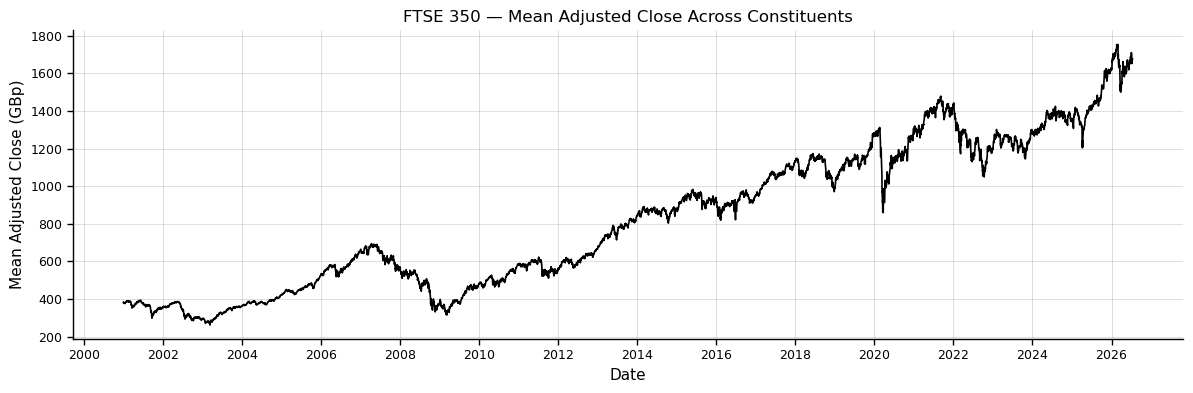

In [51]:
# Mean adjusted close across FTSE 350 constituents, EPJ-styled.
mean_price = df_clean.mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mean_price.index, mean_price.values, color=NEUTRAL_COLOURS["primary"], linewidth=1.2)
style_axis(ax, grid=True)
format_date_axis(ax, interval_years=2)
ax.set_title("FTSE 350 — Mean Adjusted Close Across Constituents")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Adjusted Close (GBp)")
fig.tight_layout()
plt.show()

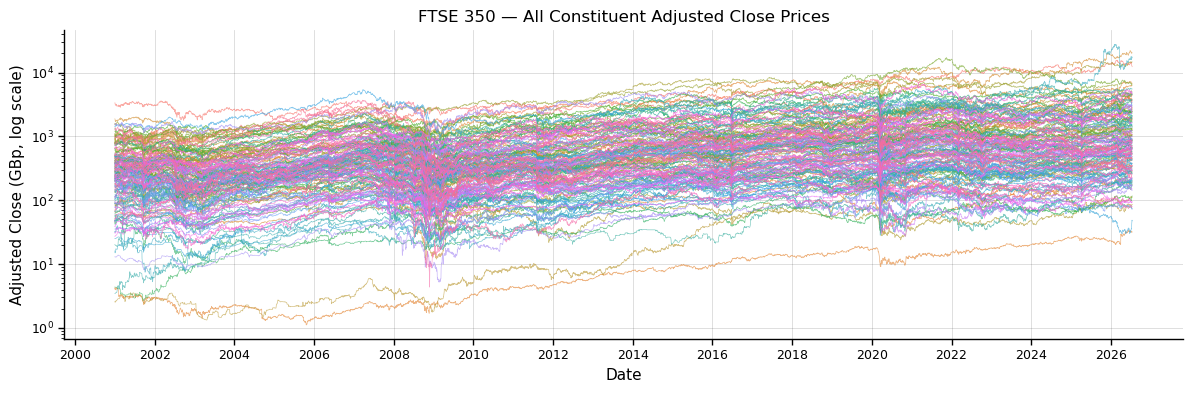

In [52]:
# All individual constituent prices overlaid, EPJ-styled (log scale: raw price levels span orders of magnitude across constituents), one colour per stock.
colours = sns.color_palette("husl", len(df_clean.columns))

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_prop_cycle(color=colours)
ax.plot(df_clean.index, df_clean.values, alpha=0.6, linewidth=0.5)
ax.set_yscale("log")
style_axis(ax, grid=True)
format_date_axis(ax, interval_years=2)
ax.set_title("FTSE 350 — All Constituent Adjusted Close Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close (GBp, log scale)")
fig.tight_layout()
plt.show()

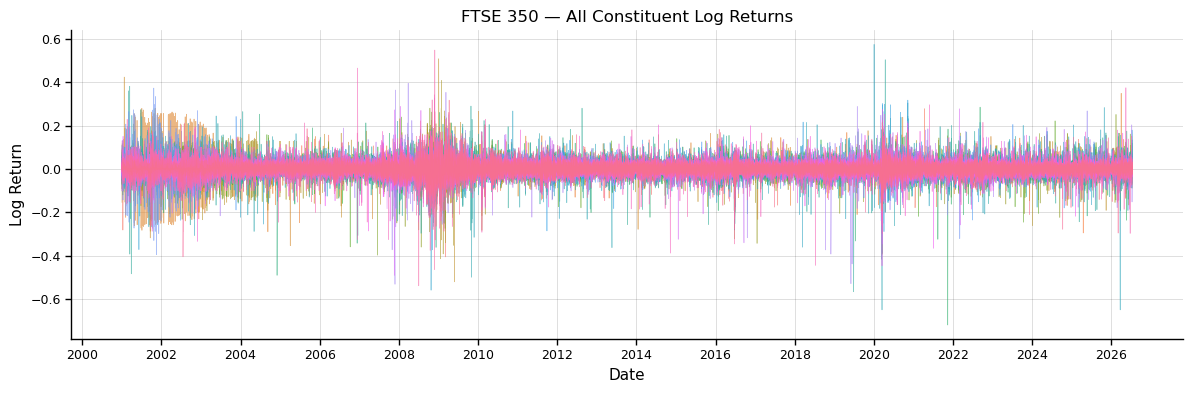

In [53]:
# All individual constituent log returns overlaid, EPJ-styled, one colour per stock.
log_returns = np.log(df_clean).diff()
colours = sns.color_palette("husl", len(log_returns.columns))

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_prop_cycle(color=colours)
ax.plot(log_returns.index, log_returns.values, alpha=0.6, linewidth=0.5)
style_axis(ax, grid=True)
format_date_axis(ax, interval_years=2)
ax.set_title("FTSE 350 — All Constituent Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
fig.tight_layout()
plt.show()

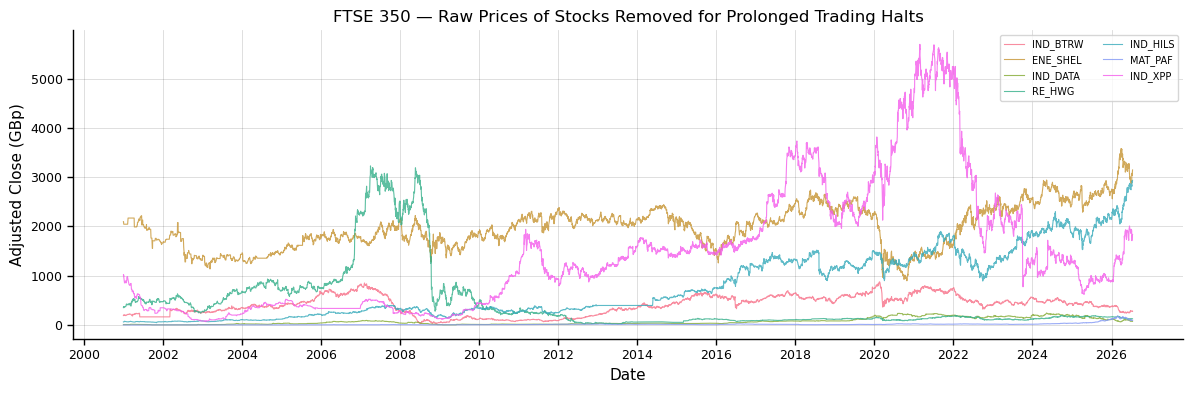

In [54]:
# Raw price series of stocks removed by the prolonged trading halt screen (FTSE 100 and FTSE 250 screened independently).
def halted_stocks(df_raw, halt_days):
    df = df_raw.drop(columns=df_raw.columns[(df_raw <= 0).any()])
    r = np.log(df).diff()
    df = df.drop(columns=r.columns[(r.abs() > 0.8).any()])
    df = df.dropna(how="any", axis=1)
    r = np.log(df).diff()
    flat = (r.abs() < 1e-12).mean(axis=1) > 0.98
    df = df.loc[~flat]
    r = np.log(df).diff()
    flat_by_stock = r.abs() < 1e-12
    longest_halt = flat_by_stock.apply(lambda s: s.groupby((~s).cumsum()).cumsum().max())
    return longest_halt[longest_halt >= halt_days].index

HALT_STREAK_DAYS = 63
halted = list(halted_stocks(df_ftse100_raw, HALT_STREAK_DAYS)) + list(halted_stocks(df_ftse250_raw, HALT_STREAK_DAYS))

if len(halted) > 0:
    colours = sns.color_palette("husl", len(halted))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_prop_cycle(color=colours)
    for stock in halted:
        raw = df_ftse100_raw if stock in df_ftse100_raw.columns else df_ftse250_raw
        ax.plot(raw.index, raw[stock], alpha=0.8, linewidth=0.8, label=stock)
    style_axis(ax, grid=True)
    format_date_axis(ax, interval_years=2)
    ax.set_title("FTSE 350 — Raw Prices of Stocks Removed for Prolonged Trading Halts")
    ax.set_xlabel("Date")
    ax.set_ylabel("Adjusted Close (GBp)")
    ax.legend(loc="best", fontsize=7, ncol=2)
    fig.tight_layout()
    plt.show()
else:
    print("No stocks removed for prolonged trading halts.")